In [14]:
from cil.optimisation.functions import LeastSquares, SVRGFunction, SGFunction
from cil.framework import AcquisitionGeometry
from cil.plugins.astra import ProjectionOperator
from cil.plugins.astra import FBP
from cil.optimisation.utilities import MetricsDiagnostics, RandomSampling
from cil.optimisation.algorithms import FISTA, ISTA

from ProxSkip import ProxSkip
from utils import StoppingCriterionTime, BM3DFunction
from skimage.metrics import peak_signal_noise_ratio as PSNR
from skimage.metrics import structural_similarity as SSIM
from xdesign import Foam, discrete_phantom

import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["image.cmap"]  = "inferno"

### PnP Variance Reduced ProxSkip on a simulated dataset

In this notebook, we play the following game. We compare algorithms by **time-to-quality**: that is, we measure how quickly each method achieves high reconstruction quality—quantified by **PSNR** and **SSIM**—with respect to the ground truth. Here, the ground truth is available, and we impose a fixed computational budget. The winner is the algorithm that attains the highest PSNR/SSIM within this time limit.

### Generate Foam Phantom

In [2]:
N = 347  # image size
density = 0.025  # attenuation density of the image
np.random.seed(1234)
gt = discrete_phantom(Foam(size_range=[0.075, 0.005], gap=2e-3, porosity=1.0), size=N - 10)
gt = gt / np.max(gt) * density
gt = np.pad(gt, 5)
gt[gt < 0] = 0

### Generate Acquisition Data with simulated noise

In [3]:
num_angles = 400 

angles = np.linspace(0, 180, num_angles, endpoint=False, dtype=np.float32)
ag2D = AcquisitionGeometry.create_Parallel2D()\
        .set_panel(num_pixels=N)\
        .set_angles(angles=angles)
ig2D = ag2D.get_ImageGeometry()
x_cil = ig2D.allocate()
x_cil.fill(gt)
A = ProjectionOperator(ig2D, ag2D, device="cpu")

# noiseless sinogram
noiseless = A.direct(x_cil)

## simulated noise
max_intensity = 2000
expected_counts = max_intensity * np.exp(-noiseless.array)
noisy_counts = np.random.poisson(expected_counts).astype(np.float32)
noisy_counts[noisy_counts == 0] = 1  # deal with 0s
y_np = -np.log(noisy_counts / max_intensity)
noisy = ag2D.allocate()
noisy.fill(y_np)

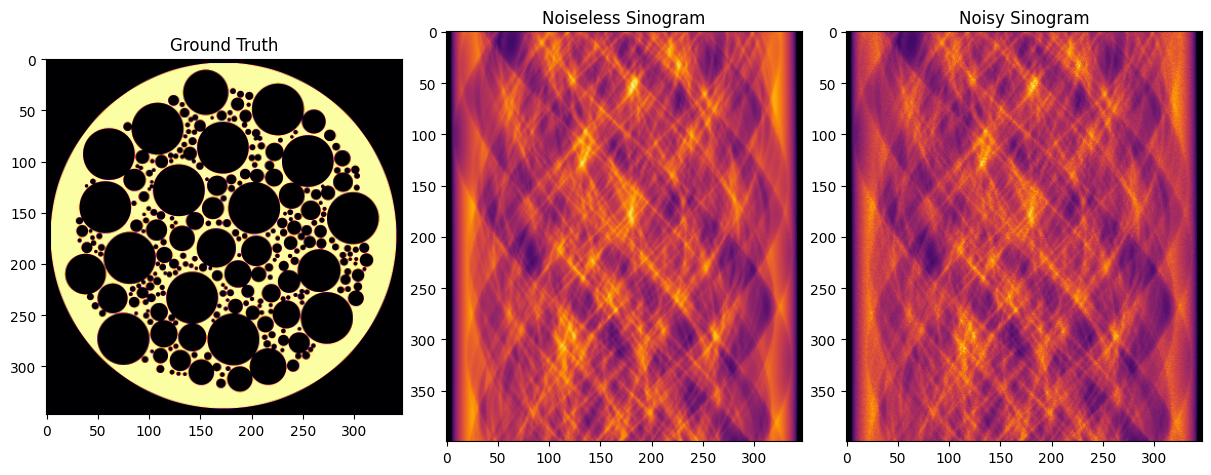

In [4]:
import numpy as np
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 3, figsize=(12, 10), constrained_layout=True)

axs[0].imshow(gt)
axs[0].set_title("Ground Truth")

axs[1].imshow(noiseless.array)
axs[1].set_title("Noiseless Sinogram")

axs[2].imshow(noisy.array)
axs[2].set_title("Noisy Sinogram")

plt.show()

### FBP reconstruction

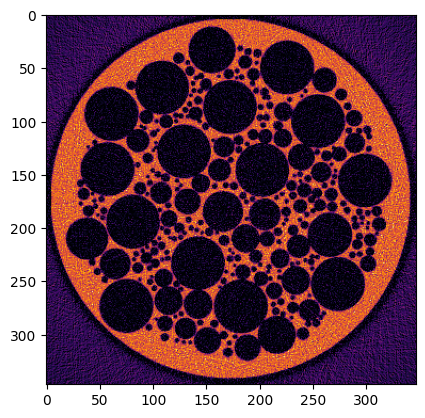

In [5]:
fbp = FBP(ig2D, ag2D, device="cpu")(noisy)
fbp.array[fbp.array<0] = 0
plt.imshow(fbp.array)

### Family of considered algorithms (ProxSkip template)

**Parameters:** $\gamma>0$, probability $p\in(0,1]$, data subsets $N$
**Initialize:** $x_0, h_0 \in \mathbb{R}^n$

For $k=0,1,\dots,K-1$:

1. Compute $G_k$ (an unbiased estimator of $\nabla f(x_k)$).
2. $$\hat x_{k+1} = x_k - \gamma\big(G_k(x_k) - h_k\big).$$
3. Sample $\theta_k\sim\mathrm{Bernoulli}(p)$, $\theta_k\in{0,1}$.
4. If $\theta_k=1$:
   $$x_{k+1}=\mathrm{prox}_{\frac{\gamma}{p}g}\left(\hat x_{k+1}-\frac{\gamma}{p}h_k\right),$$
   else:
   $$x_{k+1}=\hat x_{k+1}.$$
5. Update:
   $$h_{k+1}=h_k+\frac{p}{\gamma}\big(x_{k+1}-\hat x_{k+1}\big).$$

---

| $p=1$     | $0<p<1$       | $G_k$                                                                |
| --------- | ------------- | -------------------------------------------------------------------- |
| ISTA      | ProxSkip      | $\nabla f(x_k)$                                                      |
| ProxSGD   | ProxSGDSkip   | $N\nabla f_{i_k}(x_k)$                                               |
| ProxSAGA  | ProxSAGASkip  | $N(\nabla f_{i_k}(x_k)-v_k^{,i_k})+\bar v_k$                         |
| ProxSVRG  | ProxSVRGSkip  | $N(\nabla f_{i_k}(x_k)-\nabla f_{i_k}(\tilde x))+\nabla f(\tilde x)$ |
| ProxLSVRG | ProxLSVRGSkip | as above, updated with $p=1/N$                                       |

*Note:* FISTA is ISTA with an acceleration step (Beck & Teboulle).


### Define Stopping Criteria and Metrics (PSNR/SSIM)

In [6]:
gt_cil = ig2D.allocate()
gt_cil.fill(gt)

SSIM_ = lambda x, y: SSIM(x, y, data_range=x.max()-x.min())
PSNR_ = lambda x, y: PSNR(x, y, data_range=x.max()-x.min())

time_stop = 3*60 # 3 mins
max_iteration = 100_000

cb_metrics = MetricsDiagnostics(reference_image=gt_cil, 
                         metrics_dict={"psnr":PSNR_,"ssim":SSIM_}) 


In [7]:
### Avoid computing objectives, not needed for this demo
def update_objective(self):
    return 0.

ISTA.update_objective = update_objective
ProxSkip.update_objective = update_objective
FISTA.update_objective = update_objective

### Run deterministic algorithms: No data splitting, no skipping

In [8]:
sigma_no_skip = 0.0002 
F = LeastSquares(A=A, b=noisy, c=0.5)

### FISTA

In [9]:
initial = ig2D.allocate()
step_size = 1./F.L
G = BM3DFunction(sigma_no_skip)
cb_time = StoppingCriterionTime(time_stop)
fista = FISTA(initial = initial, f = F, step_size = step_size, g=G, 
        update_objective_interval = 1,
        max_iteration = max_iteration) 
fista.run(verbose=0, callback=[cb_metrics, cb_time])

Stop at 133 time 180.21691465377808


### ISTA

In [10]:
G = BM3DFunction(sigma_no_skip)
cb_time = StoppingCriterionTime(time_stop)
ista = ISTA(initial = initial, f = F, step_size = step_size, g=G, 
        update_objective_interval = 1,
        max_iteration = max_iteration) 
ista.run(verbose=0, callback=[cb_metrics, cb_time])

Stop at 136 time 181.1661660671234


### Run ProxSkip: Skip the regulariser

In [11]:
prob = 0.05
sigma_skip = sigma_no_skip/np.sqrt(prob)

In [12]:
G =  BM3DFunction(sigma_skip)

cb_time = StoppingCriterionTime(time_stop)
proxskip = ProxSkip(initial = [initial, initial], f = F, step_size = step_size, g=G, 
        update_objective_interval = 1, prob=prob, seed = 42, 
        max_iteration = max_iteration) 
proxskip.run(verbose=0, callback=[cb_metrics, cb_time])

Stop at 798 time 180.02409982681274


### Run stochastic algorithms: Data splitting, no skipping

In [15]:
def list_of_functions(data):
    
    list_funcs = []
    ig = data[0].geometry.get_ImageGeometry()
    
    for d in data:
        ageom_subset = d.geometry        
        Ai = ProjectionOperator(ig, ageom_subset, device = 'cpu')    
        fi = LeastSquares(Ai, b = d, c = 0.5)
        list_funcs.append(fi)   
        
    return list_funcs

In [16]:
# number of subsets
nsub = 50
data_split, method = noisy.split_to_subsets(nsub, method= "ordered", info=True)

# list of fis for finite sum 
list_func = list_of_functions(data_split) 

### ProxSVRG and ProxSGD

In [17]:
selection = RandomSampling(len(list_func), nsub, seed=42)
Fsvrg = SVRGFunction(list_func, selection = selection, update_frequency=len(list_func))
Fsvrg.initial = initial
step_size = 1./(Fsvrg.L)

G =  BM3DFunction(sigma_no_skip)
cb_time = StoppingCriterionTime(time_stop)
prox_svrg = ISTA(initial = initial, f = Fsvrg, step_size = step_size, g=G, 
            update_objective_interval = 1, 
            max_iteration = max_iteration) 
prox_svrg.run(verbose=0, callback=[cb_metrics, cb_time]) 


Stop at 153 time 180.59406900405884


In [18]:
selection = RandomSampling(len(list_func), nsub, seed=42)
Fsgd = SGFunction(list_func, selection = selection) 
step_size = 1./(Fsgd.L)

G =  BM3DFunction(sigma_no_skip)
cb_time = StoppingCriterionTime(time_stop)
prox_sgd = ISTA(initial = initial, f = Fsgd, step_size = step_size, g=G, 
            update_objective_interval = 1, 
            max_iteration = max_iteration) 
prox_sgd.run(verbose=0, callback=[cb_metrics, cb_time]) 


Stop at 150 time 181.06261777877808


### Run stochastic algorithms: Data splitting and skipping

In [19]:
selection = RandomSampling(len(list_func), nsub, seed=42)
Fsvrg_skip = SVRGFunction(list_func, selection = selection, update_frequency=len(list_func))
Fsvrg_skip.initial = initial
step_size = 1./(Fsvrg_skip.L)

G =  BM3DFunction(sigma_skip)
cb_time = StoppingCriterionTime(time_stop)
prox_svrg_skip = ProxSkip(initial = [initial, initial], f = Fsvrg_skip, step_size = step_size, g=G, 
            update_objective_interval = 1, prob=prob, seed=42,
            max_iteration = max_iteration) 
prox_svrg_skip.run(verbose=0, callback=[cb_metrics, cb_time]) 

Stop at 2581 time 180.52547121047974


In [20]:
selection = RandomSampling(len(list_func), nsub, seed=42)
Fsgd_skip = SGFunction(list_func, selection = selection)
step_size = 1./(Fsgd_skip.L)

G =  BM3DFunction(sigma_skip)
cb_time = StoppingCriterionTime(time_stop)
prox_sgd_skip = ProxSkip(initial = [initial, initial], f = Fsgd_skip, step_size = step_size, g=G, 
            update_objective_interval = 1, prob=prob, seed=42,
            max_iteration = max_iteration) 
prox_sgd_skip.run(verbose=0, callback=[cb_metrics, cb_time]) 

Stop at 2887 time 180.82532835006714


### Plot PSNR/SSIM progress
- with respect to iteration
- with respect to time

In [21]:
t_ista  = np.cumsum(ista.timing)
t_fista = np.cumsum(fista.timing)
t_proxskip    = np.cumsum(proxskip.timing)
t_prox_svrg  = np.cumsum(prox_svrg.timing)
t_prox_svrg_skip = np.cumsum(prox_svrg_skip.timing)
t_prox_sgd_skip   = np.cumsum(prox_sgd_skip.timing)

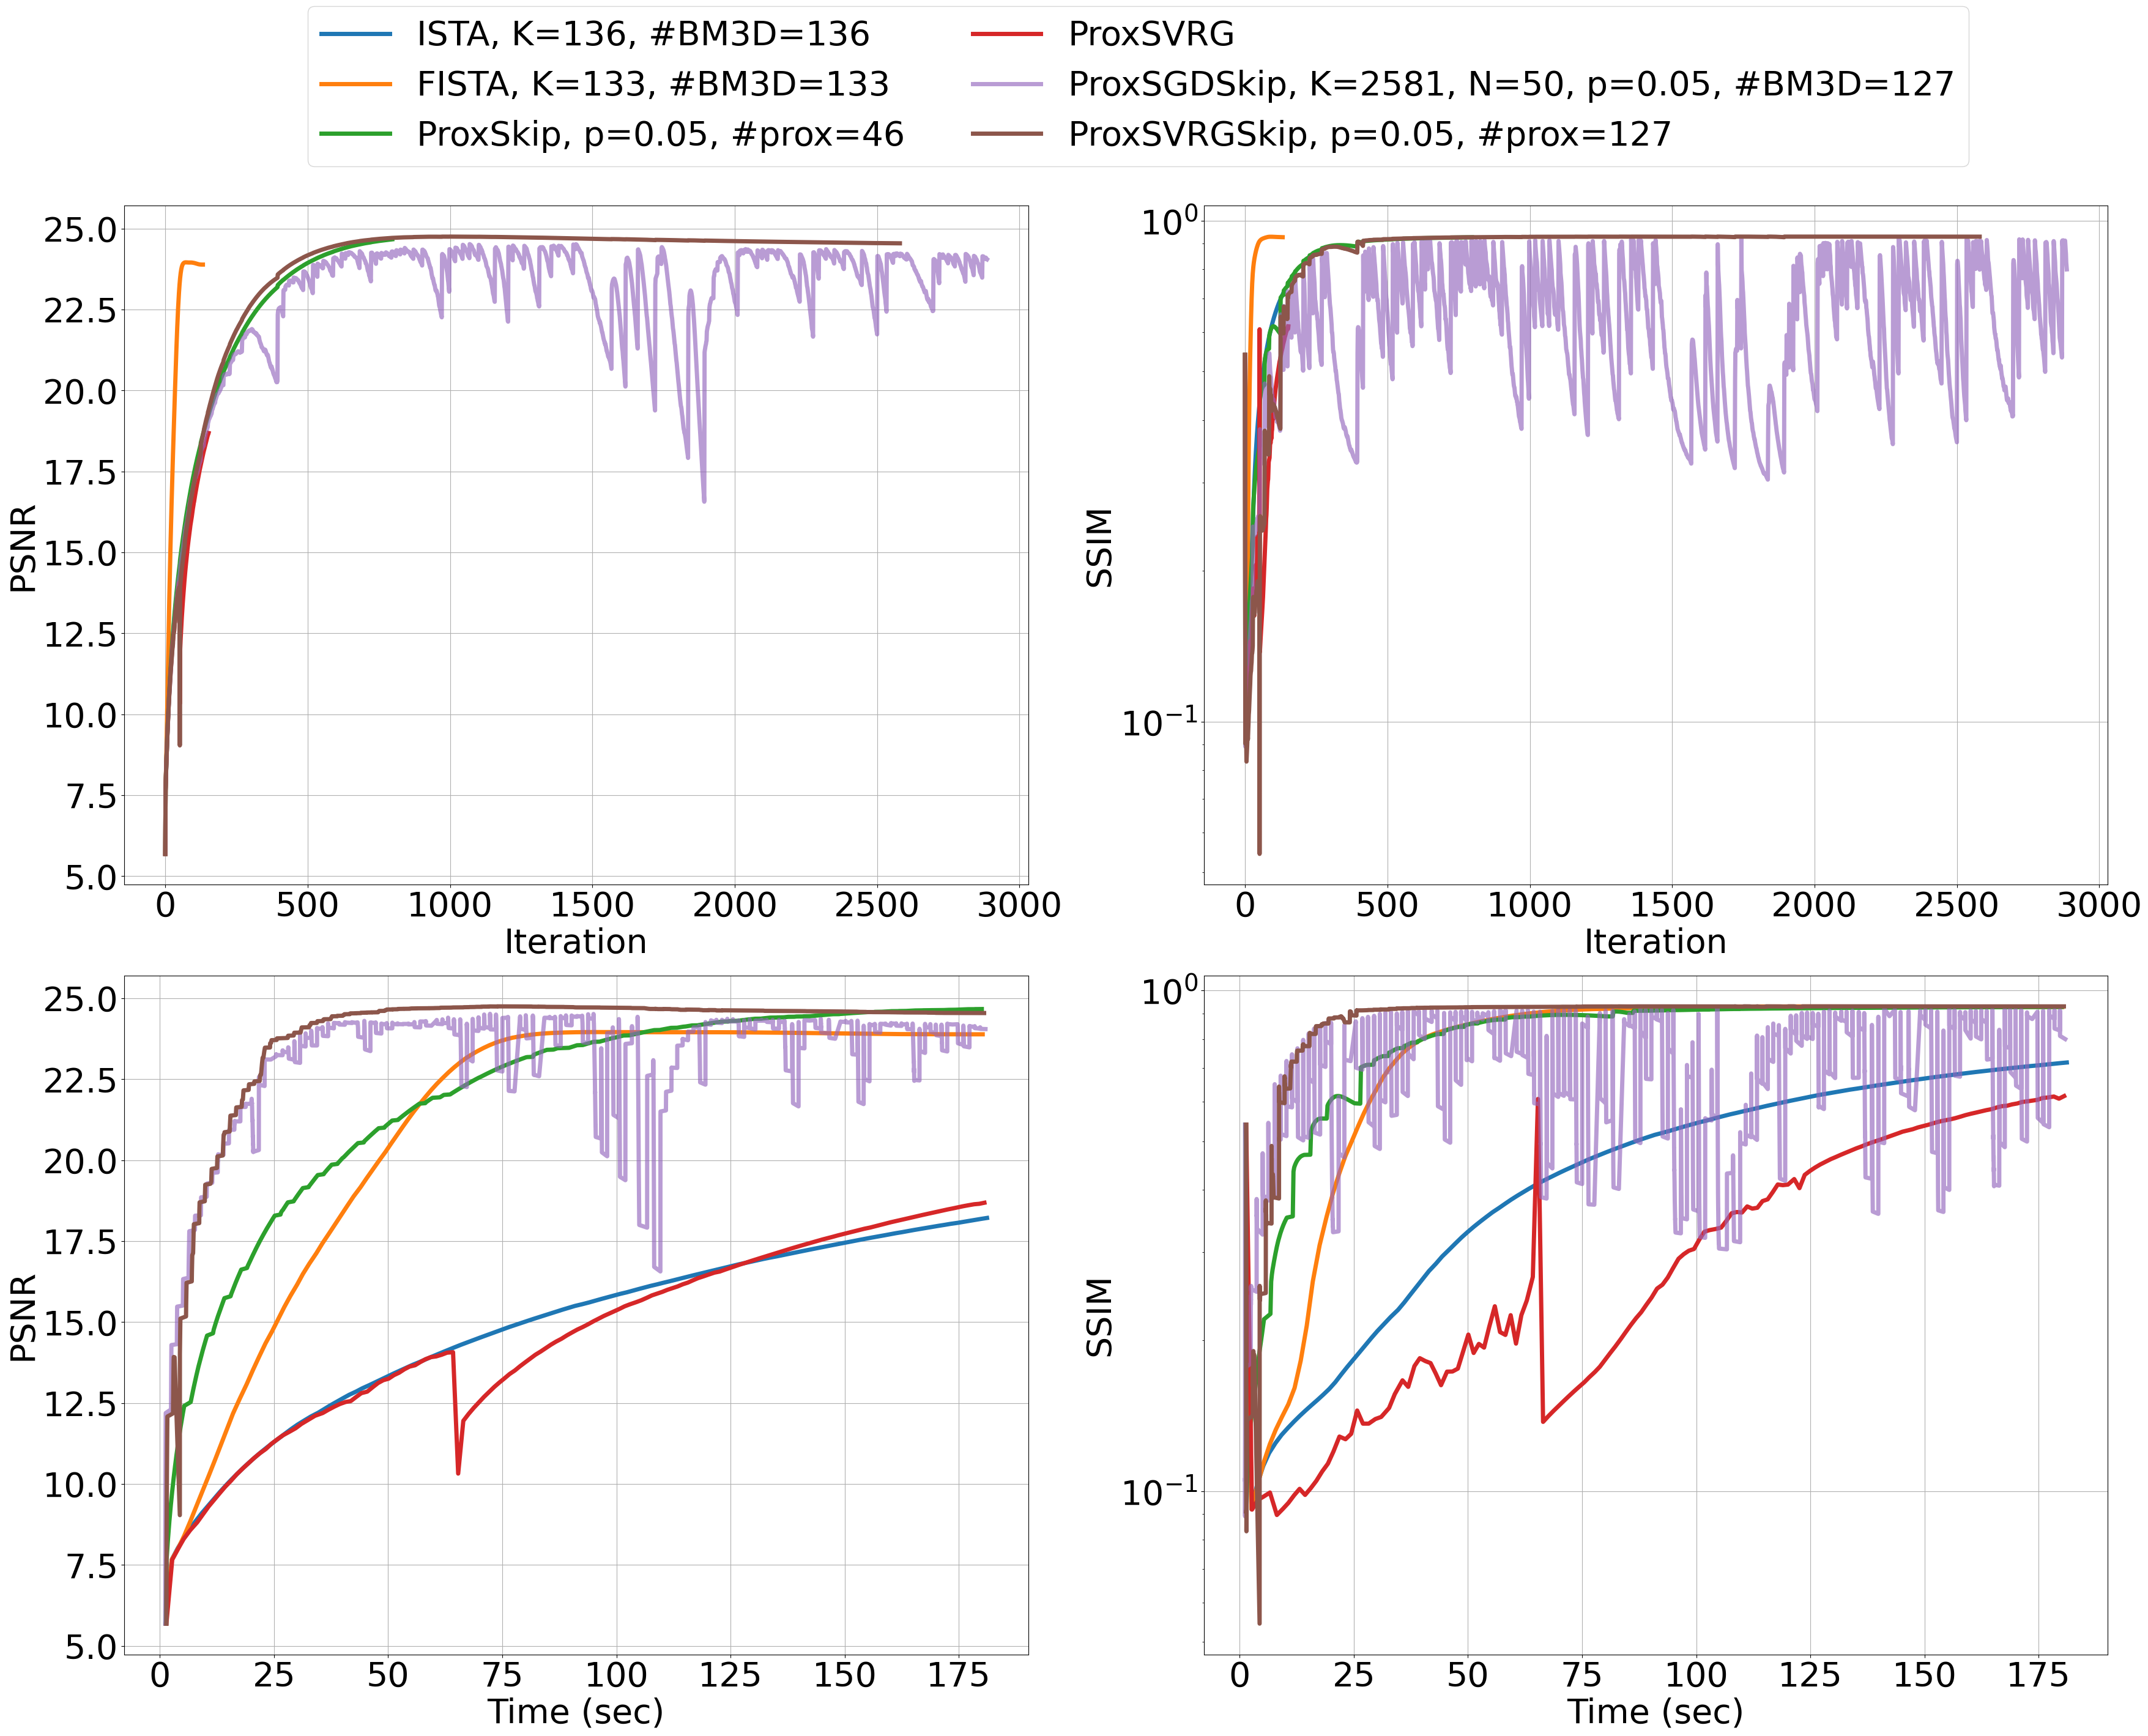

In [22]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['lines.linewidth'] = 5
plt.rcParams['lines.markersize'] = 20
plt.rcParams['font.size'] = 40

fig, ax = plt.subplots(2, 2, figsize=(35, 25), constrained_layout=True)

ax[0,0].plot(ista.psnr[:-1], label=f"ISTA, K={ista.iteration}, #BM3D={ista.iteration}")
ax[0,0].plot(fista.psnr[:-1], label=f"FISTA, K={fista.iteration}, #BM3D={fista.iteration}")
ax[0,0].plot(proxskip.psnr[:-1], label=f"ProxSkip, K={proxskip.iteration},  #BM3D={np.sum(proxskip.thetas)}")
ax[0,0].plot(prox_svrg.psnr[:-1], label=f"ProxSVRG, K={prox_svrg.iteration}, #BM3D={prox_svrg.iteration}")
ax[0,0].plot(prox_sgd_skip.psnr[:-1],label=f"ProxSGDSkip, K={prox_svrg_skip.iteration}, #BM3D={np.sum(prox_svrg_skip.thetas)}", alpha=0.65)
ax[0,0].plot(prox_svrg_skip.psnr[:-1],label=f"ProxSVRGSkip, K={prox_svrg_skip.iteration}, #BM3D={np.sum(prox_svrg_skip.thetas)}")
ax[0,0].grid(which="major")
ax[0,0].set_xlabel("Iteration")
ax[0,0].set_ylabel("PSNR")

ax[0,1].plot(ista.ssim[:-1], label=f"ISTA, K={ista.iteration}, #BM3D={ista.iteration}")
ax[0,1].plot(fista.ssim[:-1], label=f"FISTA, K={fista.iteration}, #BM3D={fista.iteration}")
ax[0,1].plot(proxskip.ssim[:-1], label=f"ProxSkip, p={prob}, #prox={np.sum(proxskip.thetas)}")
ax[0,1].plot(prox_svrg.ssim[:-1], label="ProxSVRG")
ax[0,1].semilogy(prox_sgd_skip.ssim[:-1],label=f"ProxSGDSkip, K={prox_svrg_skip.iteration}, N={nsub}, p={prob}, #BM3D={np.sum(prox_svrg_skip.thetas)}", alpha=0.65)
ax[0,1].plot(prox_svrg_skip.ssim[:-1],label=f"ProxSVRGSkip, p={prob}, #prox={np.sum(prox_svrg_skip.thetas)}")
ax[0,1].grid(which="major")
ax[0,1].set_xlabel("Iteration")
ax[0,1].set_ylabel("SSIM")

ax[1,0].plot(t_ista,  ista.psnr[:-1], label=f"ISTA, K={ista.iteration}, #BM3D={ista.iteration}")
ax[1,0].plot(t_fista, fista.psnr[:-1], label=f"FISTA, K={fista.iteration}, #BM3D={fista.iteration}")
ax[1,0].plot(t_proxskip,    proxskip.psnr[:-1], label=f"ProxSkip, K={proxskip.iteration},  #BM3D={np.sum(proxskip.thetas)}")
ax[1,0].plot(t_prox_svrg,  prox_svrg.psnr[:-1], label=f"ProxSVRG, K={prox_svrg.iteration}, #BM3D={prox_svrg.iteration}")
ax[1,0].plot(t_prox_sgd_skip, prox_sgd_skip.psnr[:-1],
               label=f"ProxSGDSkip, K={prox_svrg_skip.iteration}, #BM3D={np.sum(prox_svrg_skip.thetas)}", alpha=0.65)
ax[1,0].plot(t_prox_svrg_skip, prox_svrg_skip.psnr[:-1],
               label=f"ProxSVRGSkip, K={prox_svrg_skip.iteration}, #BM3D={np.sum(prox_svrg_skip.thetas)}")
ax[1,0].grid(which="major")
ax[1,0].set_xlabel("Time (sec)")
ax[1,0].set_ylabel("PSNR")

ax[1,1].plot(t_ista,  ista.ssim[:-1], label=f"ISTA, K={ista.iteration}, #BM3D={ista.iteration}")
ax[1,1].plot(t_fista, fista.ssim[:-1], label=f"FISTA, K={fista.iteration}, #BM3D={fista.iteration}")
ax[1,1].plot(t_proxskip,    proxskip.ssim[:-1], label=f"ProxSkip, p={prob}, #prox={np.sum(proxskip.thetas)}")
ax[1,1].plot(t_prox_svrg,  prox_svrg.ssim[:-1], label="ProxSVRG")
ax[1,1].semilogy(t_prox_sgd_skip, prox_sgd_skip.ssim[:-1],
               label=f"ProxSGDSkip, K={prox_svrg_skip.iteration}, N={nsub}, p={prob}, #BM3D={np.sum(prox_svrg_skip.thetas)}", alpha=0.65)
ax[1,1].plot(t_prox_svrg_skip, prox_svrg_skip.ssim[:-1],
           label=f"ProxSVRGSkip, p={prob}, #prox={np.sum(prox_svrg_skip.thetas)}")
ax[1,1].grid(which="major")
ax[1,1].set_xlabel("Time (sec)")
ax[1,1].set_ylabel("SSIM")

handles, labels = ax[0,1].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.53, 1.14),
           ncols=2, frameon=True)


plt.show()


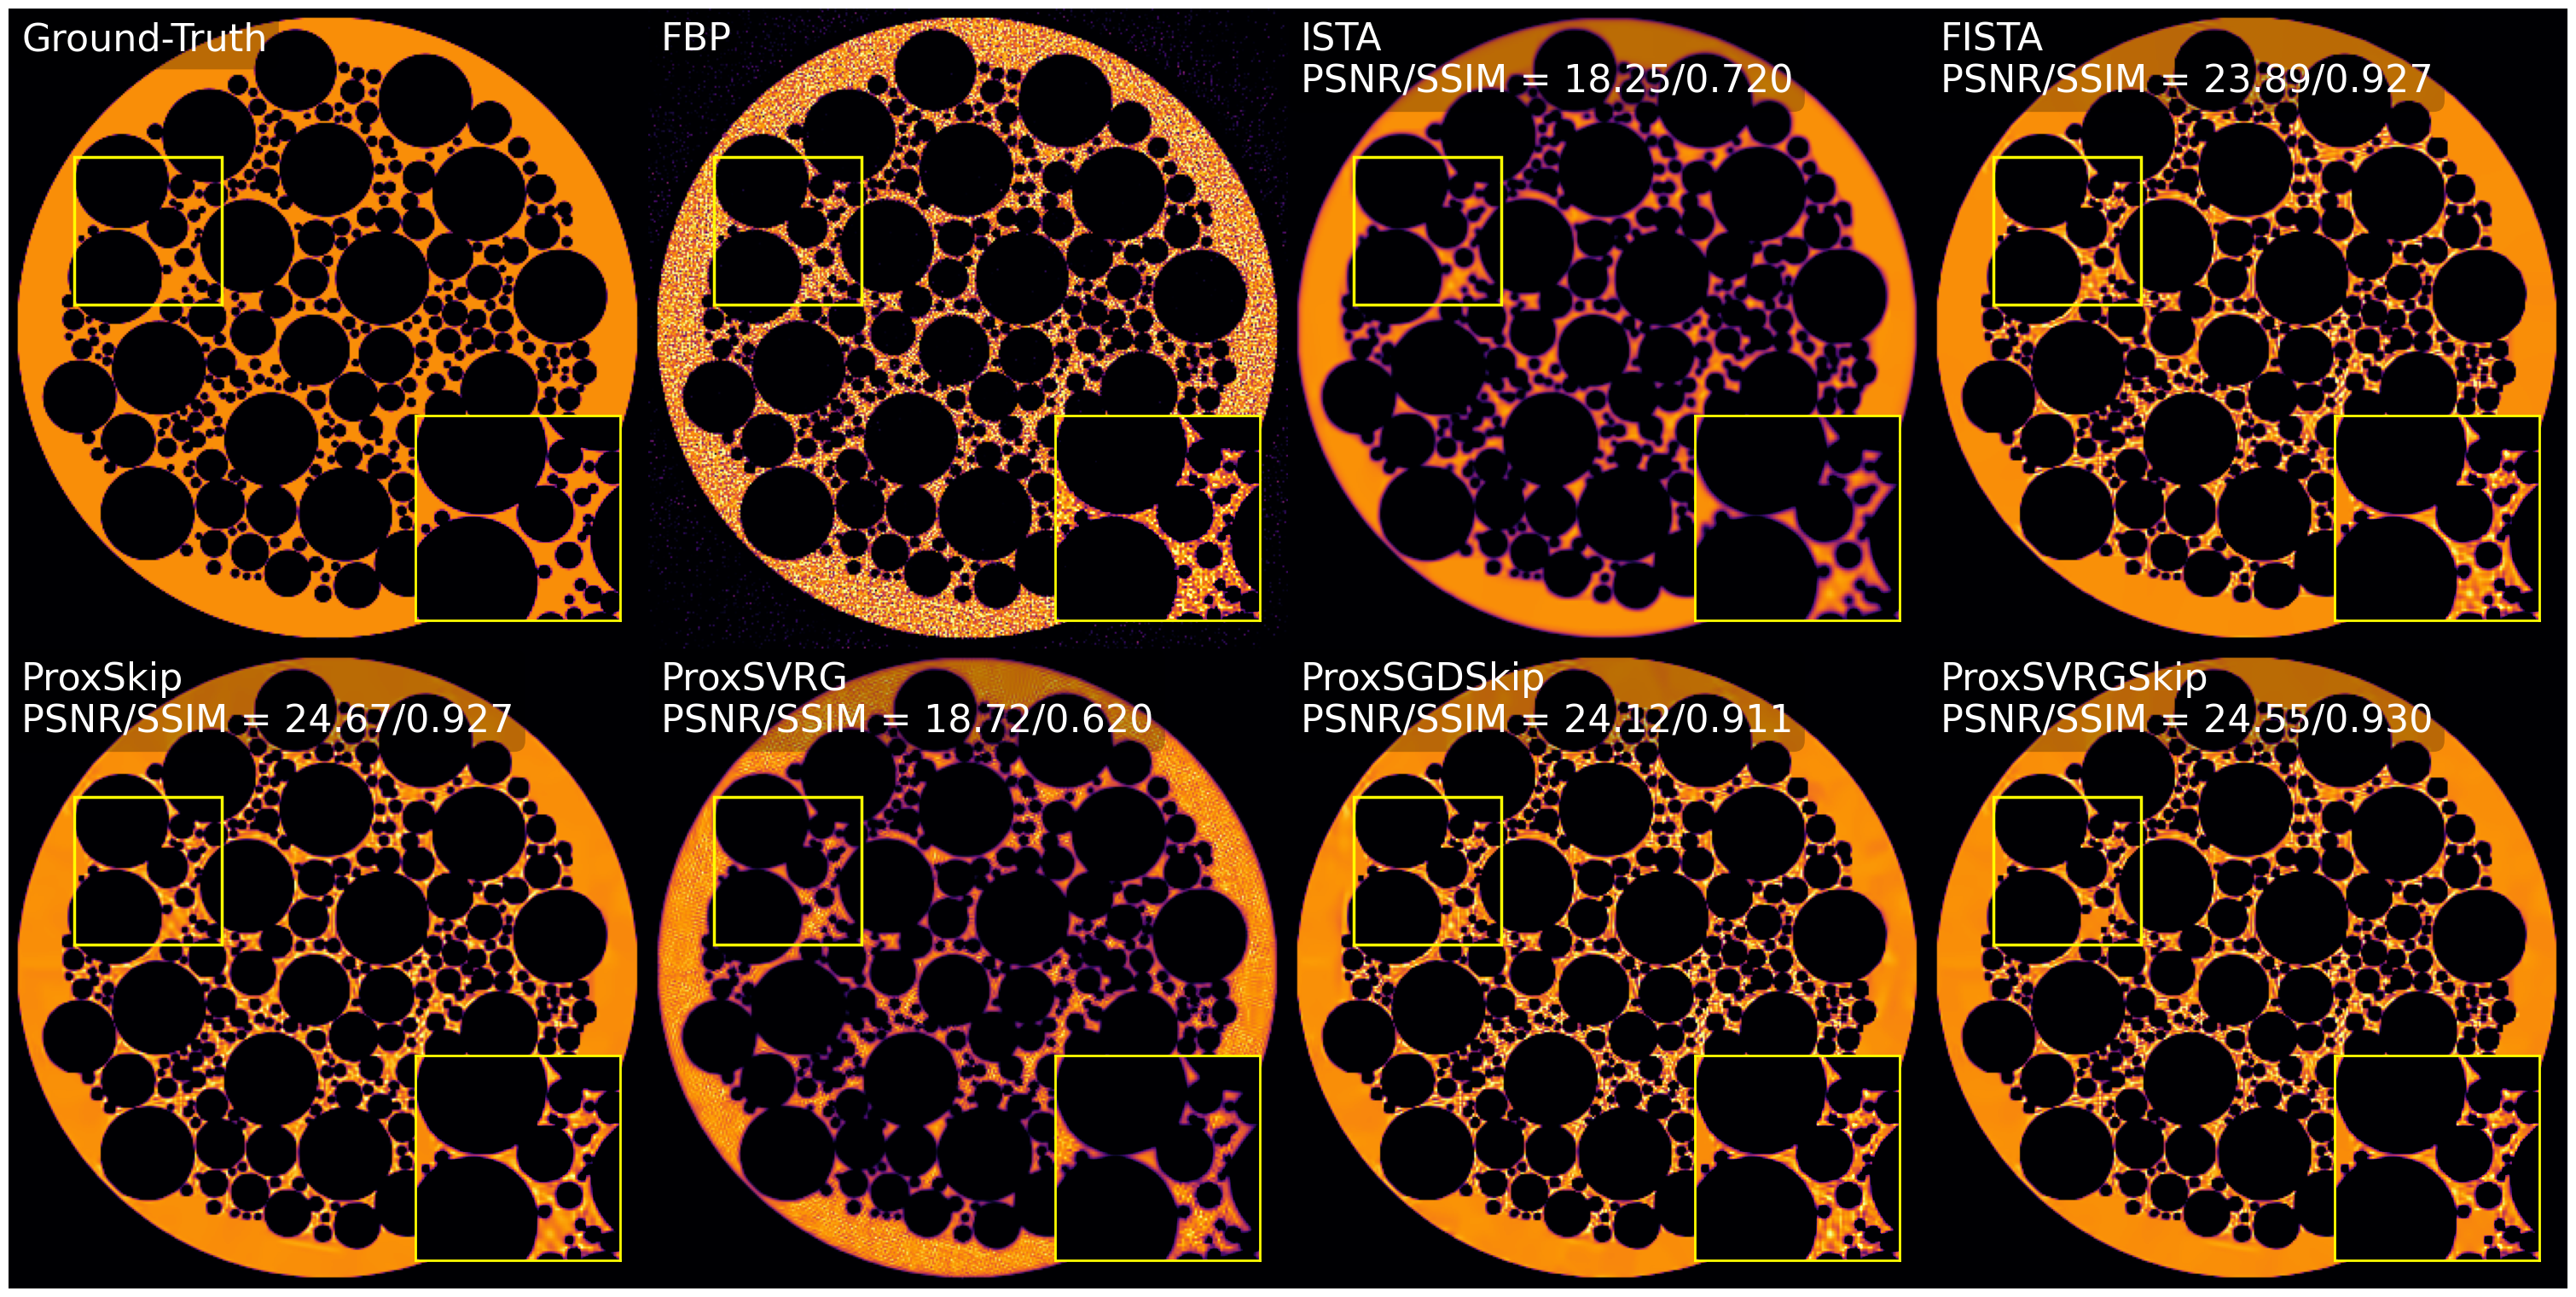

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Rectangle

imgs = [
    x_cil.array,
    fbp.array, 
    ista.solution.array,
    fista.solution.array,
    proxskip.solution.array,
    prox_svrg.solution.array,
    prox_sgd_skip.solution.array,
    prox_svrg_skip.solution.array,
]

labels = [
    "Ground-Truth",
    f"FBP",
    f"ISTA\nPSNR/SSIM = {ista.psnr[-1]:.2f}/{ista.ssim[-1]:.3f}",
    f"FISTA\nPSNR/SSIM = {fista.psnr[-1]:.2f}/{fista.ssim[-1]:.3f}",
    f"ProxSkip\nPSNR/SSIM = {proxskip.psnr[-1]:.2f}/{proxskip.ssim[-1]:.3f}",
    f"ProxSVRG\nPSNR/SSIM = {prox_svrg.psnr[-1]:.2f}/{prox_svrg.ssim[-1]:.3f}",
    f"ProxSGDSkip\nPSNR/SSIM = {prox_sgd_skip.psnr[-1]:.2f}/{prox_sgd_skip.ssim[-1]:.3f}",
    f"ProxSVRGSkip\nPSNR/SSIM = {prox_svrg_skip.psnr[-1]:.2f}/{prox_svrg_skip.ssim[-1]:.3f}",
]

vmax = max(np.max(im) for im in imgs)
vmin = 0.01
vmax = 0.03

h, w = imgs[0].shape[:2]
img_aspect = w / h
nrows, ncols = 2, 4

fig_h = 15
fig_w = fig_h * (ncols / nrows) * img_aspect

fig = plt.figure(figsize=(fig_w, fig_h))
gs = fig.add_gridspec(nrows, ncols, wspace=0, hspace=0)
axes = np.array([fig.add_subplot(gs[i, j]) for i in range(nrows) for j in range(ncols)])
fig.subplots_adjust(left=0, right=1, bottom=0, top=1)

H, W = imgs[0].shape[:2]
roi_size = 80
cx, cy = 75, 120  

x0 = cx - roi_size // 2
x1 = x0 + roi_size
y0 = cy - roi_size // 2
y1 = y0 + roi_size

x0 = max(0, min(x0, W - roi_size)); x1 = x0 + roi_size
y0 = max(0, min(y0, H - roi_size)); y1 = y0 + roi_size

inset_size = "32%"
inset_borderpad = 0.6

for ax, im, txt in zip(axes, imgs, labels):
    ax.imshow(im, cmap="inferno", vmin=vmin, vmax=vmax)
    ax.axis("off")

    ax.text(
        0.02, 0.98, txt,
        transform=ax.transAxes,
        ha="left", va="top",
        color="white", fontsize=32,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="black", alpha=0.25, edgecolor="none")
    )

    rect = Rectangle((x0, y0), roi_size, roi_size,
                     linewidth=2.5, edgecolor="yellow", facecolor="none")
    ax.add_patch(rect)

    axins = inset_axes(ax, width=inset_size, height=inset_size,
                       loc="lower right", borderpad=inset_borderpad)
    axins.imshow(im, cmap="inferno", vmin=vmin, vmax=vmax)
    axins.set_xlim(x0, x1)
    axins.set_ylim(y1, y0) 
    axins.set_xticks([])
    axins.set_yticks([])
    for spine in axins.spines.values():
        spine.set_linewidth(2)
        spine.set_edgecolor("yellow")

plt.show()
